# Práctica de aprendizaje automático (parte 1)

Entrega este cuaderno habiendo **ejecutado todas las celdas**. Incluye en la entrega **todos los ficheros necesarios para su ejecución**.

Asegúrate de que la presentación está bien estructurada: Se valorará la **claridad, concisión, y completitud** del informe.


## 1. Construcción de clasificadores en bases de datos sintéticas

In [1]:
# Fuente:
# http://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html

In [ ]:
import numpy as np
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

import sys
sys.path.insert(0, './tools')
from tools.tools_assignment_1 import plot_classifiers

%matplotlib inline

In [3]:
# Datos sintéticos

simple = make_blobs(n_samples=500, n_features=2,
                    centers=[[0,0], [2.5,2.5]],
                    random_state=1)
X,y = make_blobs(n_samples=500, n_features=2,
                 centers=[[0,0], [5,1]],
                 random_state=1)
X = X @ np.asarray([[1,-2],[-20,10]])
linearly_separable=(X,y)

datasets = [
    simple,
    linearly_separable,
    make_moons(noise=0.1, random_state=0, n_samples=500),
    make_circles(
        noise=0.1, 
        factor=0.5, 
        random_state=1,
        n_samples=500
    )
]

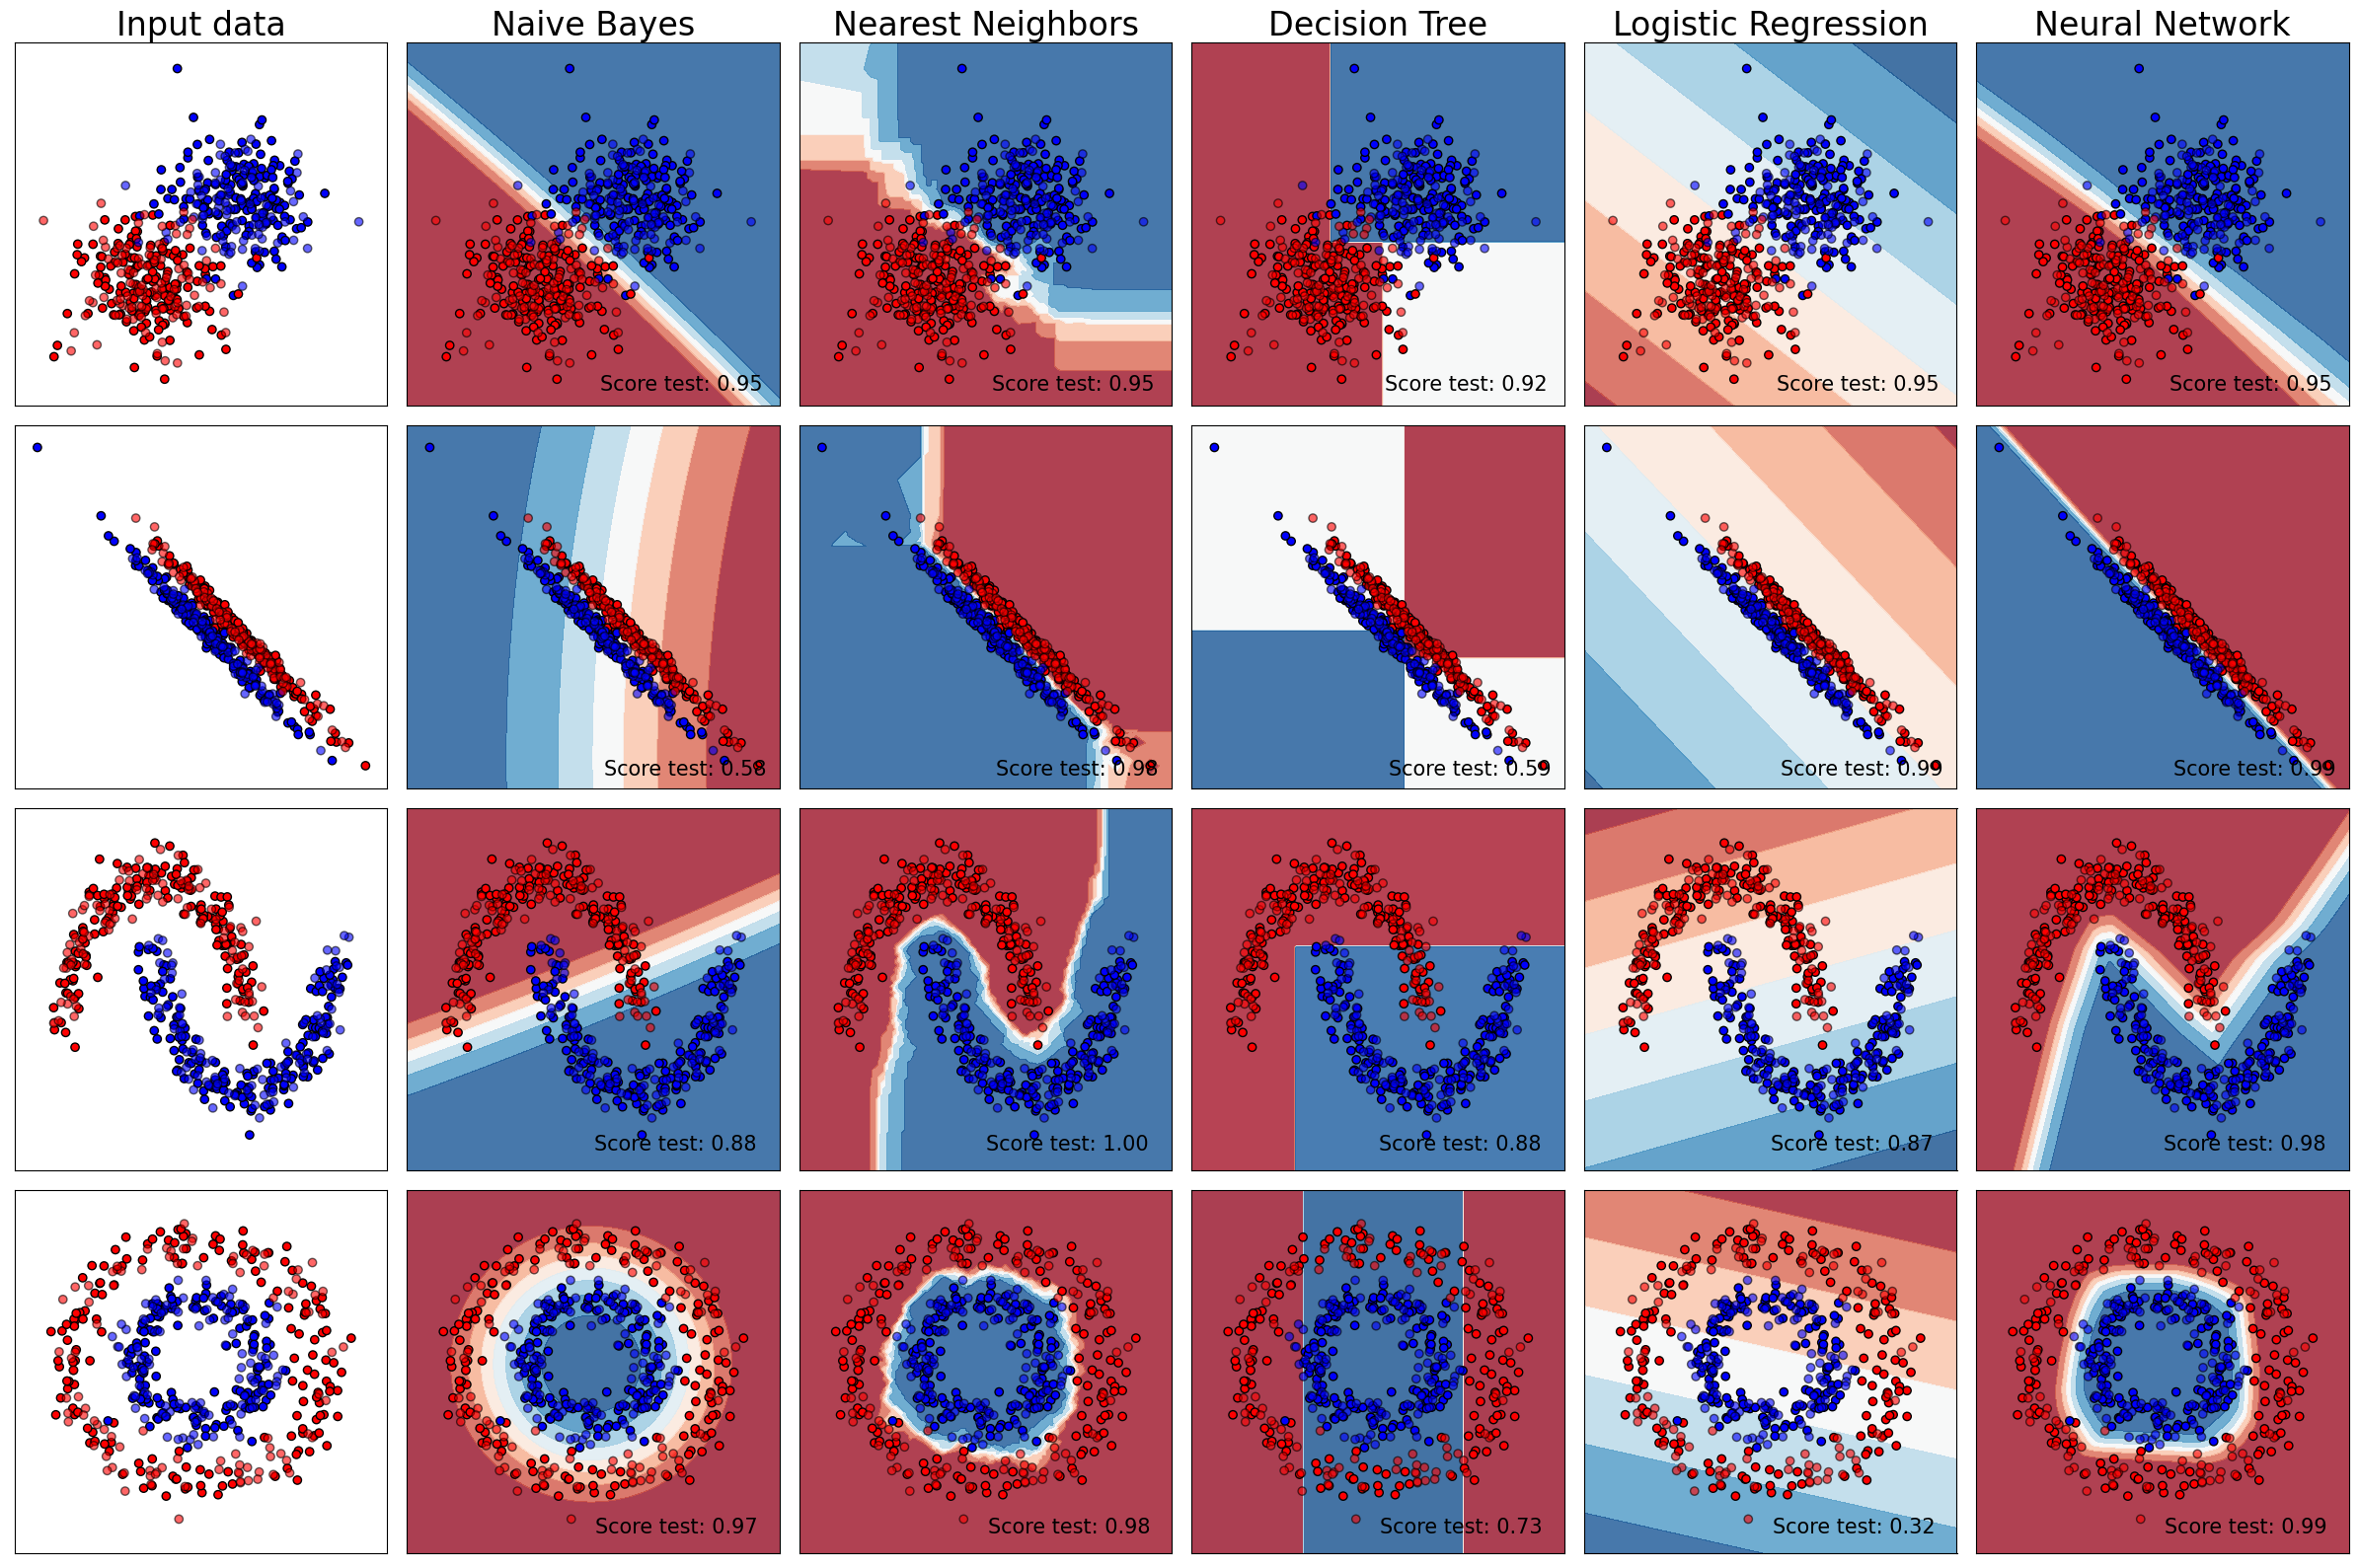

In [4]:
classifiers = [("Naive Bayes", GaussianNB()),
               ("Nearest Neighbors",
                KNeighborsClassifier(p=1, metric='minkowski', n_neighbors=7, weights='distance')),
               ("Decision Tree",
                DecisionTreeClassifier(criterion='entropy',
                                       max_depth=2)), 
               ("Logistic Regression",
                LogisticRegression(C=1.0e10, solver='lbfgs')), 
               # C: controls the level of regularization (larger C, less regularized) 
               ("Neural Network",
                MLPClassifier(hidden_layer_sizes=(50,),
                              max_iter=1000,
                              alpha=0.0))]

plot_classifiers(classifiers, datasets)

In [5]:
# Hyperparameters of the different classifiers.
for name, clf in classifiers:
    print(clf)

GaussianNB()
KNeighborsClassifier(n_neighbors=7, p=1, weights='distance')
DecisionTreeClassifier(criterion='entropy', max_depth=2)
LogisticRegression(C=10000000000.0)
MLPClassifier(alpha=0.0, hidden_layer_sizes=(50,), max_iter=1000)


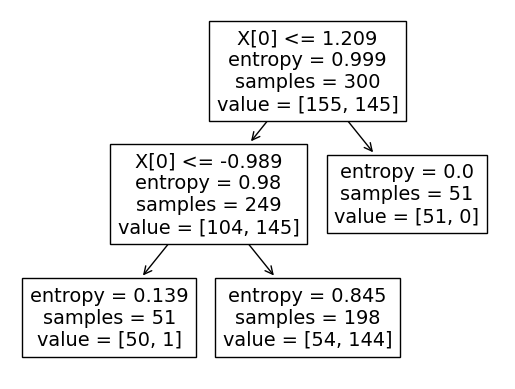

In [6]:
# Decision tree: Structure, hyperparameters, and node properties.
_ = plot_tree(classifiers[2][1])

### Ejercicio 1.1: Exploración de vecinos próximos.

1. Haz una gráfica de la dependencia del error de clasificación en función del número de vecinos próximos que se utilizan para realizar la predicción, con `n_neighbors = (1, 3, 7, 11, 15, 21, 31, 51, 101, ...)`.

2. Número de vecinos en k-nn.
    * ¿por qué se explora el hiperparámetro `n_neighbors`en una escala aproximadamente logarítmica?
    * ¿Debería ser impar cuando hay dos clases? Justifica la respuesta.
    * ¿Debería ser impar cuando hay más de dos clases? Justifica la respuesta
    
3. Comenta la dependencia del error de clasificación con el número de vecinos.

4. Haz una gráfica similar a las obtenidas en este cuaderno con `plot_classifiers(classifiers, datasets)` para cinco de los clasificadores de vecinos próximos entrenados. Elige las cinco que ilustren tus conclusiones.

5. Comenta la forma de la frontera de decisión dependiendo del número de vecinos.


**Referencia**: https://scikit-learn.org/stable/modules/neighbors.html


### Ejercicio 1.2: Exploración de árboles de decisión.


1. Haz una gráfica de la dependencia del error de clasificación en función de la profundidad máxima del árbol de decisión `max_depth = (1, 2, 3, 4, 5,...)`.

2. Profundidad máxima
    * ¿por qué se explora el hiperparámetro `max_depth` es una escala lineal?
    * Haz una gráfica de la profundidad del árbol generado en función de `max_depth`.
3. Comenta la dependencia del error de clasificación con la profundidad máxima del árbol.

4. Haz una gráfica similar a las obtenidas en este cuaderno con `plot_classifiers(classifiers, datasets)` para cinco de los distintos árboles entrenados. Elige los cinco que ilustren tus conclusiones.

5. Comenta la forma de la frontera de decisión dependiendo de la profundidad máxima del árbol.


**Referencia**: https://scikit-learn.org/stable/modules/tree.html#classification
    

### Ejercicio 1.3: Exploración de redes neuronales

1. Haz una gráfica de la dependencia del error de clasificación de una red neuronal con una sola capa oculta en función del número de neuronas en la capa oculta. `hidden_layer_sizes = ((1,), (2,), (3,),...).

2. Comenta la dependencia del error de clasificación con el número de neuronas en la capa oculta.

3. Haz una gráfica similar a las obtenidas en este cuaderno con `plot_classifiers(classifiers, datasets)` para cinco de las distintas redes neuronales entrenadas. Elige las cinco que ilustren tus conclusiones.

4. Comenta la forma de la frontera de decisión dependiendo del número de neuronas en la capa oculta.


**Referencia**: https://scikit-learn.org/stable/modules/neural_networks_supervised.html

### Ejercicio 1.4: Exploración de redes neuronales profundas

1. Haz una gráfica de la dependencia del error de clasificación de una red neuronal en función del número de capas ocultas `hidden_layer_sizes = ((5,), (5, 5,), (5, 5, 5,),...)`

2. Comenta la dependencia del error de clasificación con el número de capas ocultas.

3. Haz una gráfica similar a las obtenidas en este cuaderno con `plot_classifiers(classifiers, datasets)` para cinco de las distintas redes neuronales entrenadas. Elige las cinco que ilustren tus conclusiones.

4. Comenta la forma de la frontera de decisión dependiendo del número de capas ocultas.
